# Reuse a solved project

In this tutorial we solve and reduce a waveguide section in one project, then
use it twice in a second project, next to a new part, without solving it again.
We read the solve plan, check the joined model against the exact solution,
turn the reference to the first project into a copy, and see what happens when
the new project asks for more than the first one computed.

**Prerequisites:** [Repeat a section](repeated_sections.ipynb).

## 1. Solve a section in its own project

This is the "earlier" project: a 100 mm section, swept and reduced up to
2.9 GHz, where TE10 is the only mode that travels (TE20 and TE01 start at
3.0 GHz), so one port mode per port is enough to join copies of it.

In [1]:
from pathlib import Path

from cavsim3d.core.em_project import EMProject

source = EMProject(name="reuse_source", base_dir="./simulations", overwrite=True)
source.create_primitive("rwg", name="section", a=0.1, b=0.05, L=0.1, maxh=0.02)
source.fds.solve(fmin=0.5, fmax=2.9, nsamples=25)
source.fds.fom.reduce(tol=1e-6)

source_path = source.project_path
print("source project:", source_path)

✅ Creating new project 'reuse_source' at simulations\reuse_source



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 282



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 2 total modes



FDS Solve: 0.5000 - 2.9000 GHz, 25 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 7.07s (total iteration steps: 2627)


Model Order Reduction


Reduction complete: 6393 -> 11 DOFs (99.8% compression)


source project: simulations\reuse_source


The source now holds a full-order and a reduced model of the section.

## 2. Use it in a new project

### 2.1 Import the solved project as a part

`import_project` adds another project as a part. `n=2` uses it twice.

In [2]:
proj = EMProject(name="reuse_chain", base_dir="./simulations", overwrite=True)

section = proj.import_project(source_path, name="section", n=2)
print(section)

✅ Creating new project 'reuse_chain' at simulations\reuse_chain


ImportedModel('reuse_source', mode='reference', has=rom, ports=['port1', 'port2'], band=[0.5, 2.9] GHz)


The handle says what the imported project holds (its reduced model, its ports
and the band it was trained on) and how it is used: `reference`, the default.
A referenced project is read where it is; nothing is copied.

### 2.2 Add a new part after it

In [3]:
proj.create_primitive("rwg", name="stub", a=0.1, b=0.05, L=0.05, maxh=0.02)
print(proj.geometry.describe_layout())

Main axis: Z (default). Parts follow the list order along +Z:
  1. section x2: imported project
  2. stub: z = [1, 1.05] m
Mesh strategy: coupled (each unique part meshed and solved on its own, joined through port modes; imported: section; repeated: section (n=2))


The chain is `section x2`, the imported project, followed by `stub`. All parts
are `coupled`: an imported part always joins the others through its port
modes.

## 3. Solve with the imported part

### 3.1 Read the solve plan

In [4]:
fom_res = proj.fds.solve(fmin=0.5, fmax=2.9, nsamples=25)

✅ Mesh strategy: coupled (imported: section; repeated: section (n=2)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  section  imported (reference) reuse     its reduced model fits the request
  stub     geometry             compute   full-order solve, 25 samples



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 178
✅ Section 'stub': full-order solve


Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1


	port2 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 2 total modes



FDS Solve: 0.5000 - 2.9000 GHz, 25 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 5.73s (total iteration steps: 2401)


✅ Netlist FOM stage complete: 2 unique section(s) for 3 instance(s)


Before anything is computed, `solve()` prints a plan with one line per unique
part. `section` is reused: its saved results fit the request. `stub` is new, so
it gets a full-order solve.

### 3.2 Reduce and join

In [5]:
concat = proj.fds.foms.reduce(tol=1e-6).concatenate()
res = concat.solve(fmin=0.5, fmax=2.9, nsamples=2000)
print(f"{len(concat.structures)} sections joined")

Model Order Reduction


Reduction complete: 4104 -> 9 DOFs (99.8% compression)



Concat Solve: 0.5 - 2.9 GHz, 2000 samples, system size 29


  Concat solve complete: 0.018s (2000 frequencies)


3 sections joined


Three sections: two copies of the imported one and the stub.

### 3.3 Check against the exact solution

Two 100 mm sections and a 50 mm stub make a uniform 250 mm guide.

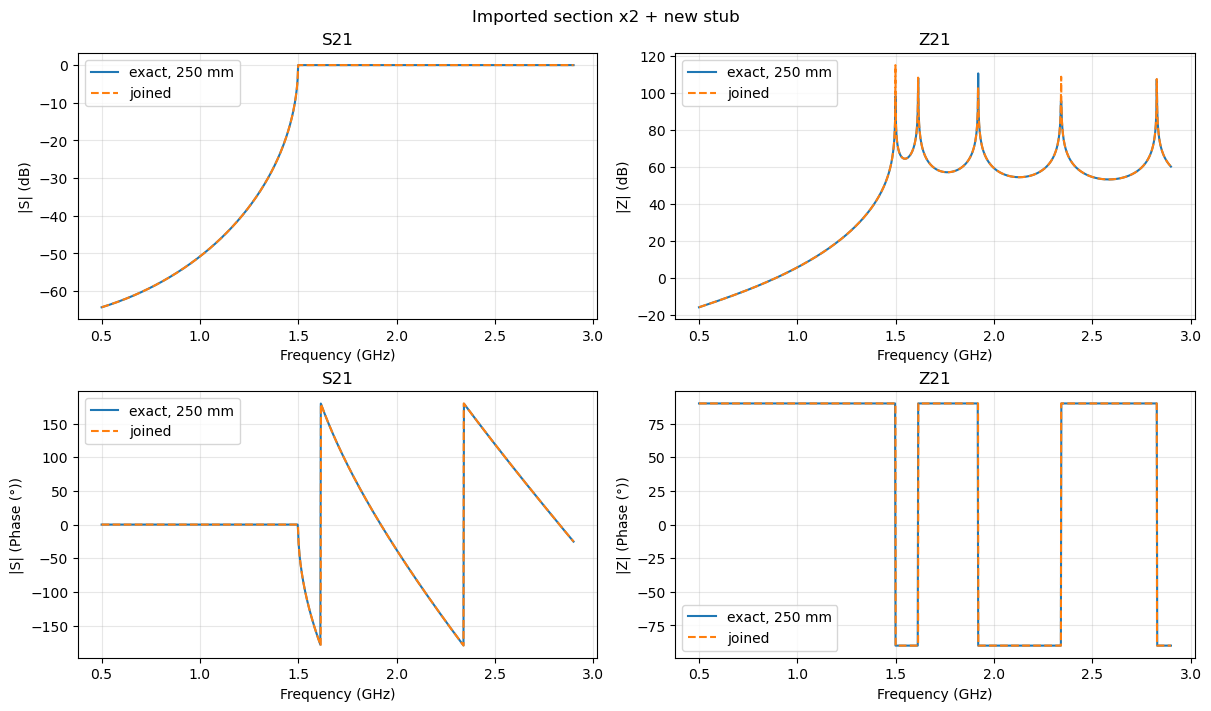

median |S21 - exact| above 1.6 GHz: 4.4e-05


In [6]:
import matplotlib.pyplot as plt
import numpy as np

from cavsim3d.analytical import RWGAnalytical

ana = RWGAnalytical(a=0.1, b=0.05, L=0.25, freq_range=(0.5, 2.9))

fig, axs = plt.subplot_mosaic([["S db", "Z db"], ["S phase", "Z phase"]],
                              figsize=(12, 7), layout="constrained")
for kind in ("db", "phase"):
    ana.plot_s(["1(1)2(1)"], plot_type=kind, ax=axs[f"S {kind}"], label="exact, 250 mm")
    concat.plot_s(["1(1)2(1)"], plot_type=kind, ax=axs[f"S {kind}"], label="joined",
                  ls="--", title="S21")
    ana.plot_z(["1(1)2(1)"], plot_type=kind, ax=axs[f"Z {kind}"], label="exact, 250 mm")
    concat.plot_z(["1(1)2(1)"], plot_type=kind, ax=axs[f"Z {kind}"], label="joined",
                  ls="--", title="Z21")
fig.suptitle("Imported section x2 + new stub")
plt.show()

f = res["frequencies"]
err = np.abs(res["S"][:, 1, 0] - ana.s_parameters(f / 1e9)["S21"])
print(f"median |S21 - exact| above 1.6 GHz: {np.median(err[f > 1.6e9]):.1e}")

The joined model matches the exact 250 mm guide in $S_{21}$ and $Z_{21}$.

## 4. Reference or copy

### 4.1 See what the reference stored

The project's reduced models live in `fds/foms/roms/matrices/`, one file per
section and matrix, named after the section. List them:

In [7]:
roms_dir = Path(proj.project_path) / "fds" / "foms" / "roms" / "matrices"
print(sorted(p.name for p in roms_dir.iterdir()))

['A_r_stub.h5', 'B_r_stub.h5', 'Q_L_inv_stub.h5', 'W_stub.h5']


Only the stub's files are there: the section is still read from the source
project. `fds/imports.json` records where the source is and a fingerprint of
its results; reopening this project warns if the source has moved or changed.

### 4.2 Turn the reference into a copy

Before sharing or archiving a project, copy what it references into it:

In [8]:
n_copied = proj.localize()
print(f"{n_copied} part(s) copied")
print(sorted(p.name for p in roms_dir.iterdir()))

✅ Localized 1 part(s): ['section']


1 part(s) copied
['A_r_section.h5', 'A_r_stub.h5', 'B_r_section.h5', 'B_r_stub.h5', 'Q_L_inv_section.h5', 'Q_L_inv_stub.h5', 'W_section.h5', 'W_stub.h5']


The section's files are now in the project too, named after the part
(`..._section.h5`) next to the stub's. The project no longer needs the source.
(To copy from the start, import with `mode="copy"`.)

## 5. When the source does not fit

### 5.1 Ask for a wider band

The source was trained on 0.5 to 2.9 GHz. A new project that needs 3.5 GHz
cannot reuse its reduced model.

In [9]:
wide = EMProject(name="reuse_wider", base_dir="./simulations", overwrite=True)
wide.import_project(source_path, name="section", n=2)
wide_res = wide.fds.solve(fmin=0.5, fmax=3.5, nsamples=31, rerun=True)

✅ Creating new project 'reuse_wider' at simulations\reuse_wider


✅ Mesh strategy: coupled (imported: section; repeated: section (n=2)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  section  imported (reference) recompute band 0.5-3.5 GHz is not covered by its 0.5-2.9 GHz



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 282
✅ Section 'section': full-order solve


Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 2 total modes



FDS Solve: 0.5000 - 3.5000 GHz, 31 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 9.26s (total iteration steps: 3678)


✅ Netlist FOM stage complete: 1 unique section(s) for 2 instance(s)


The plan now says `recompute`: the section is solved again from the source's
geometry, **inside this project**. In a script, where nobody can confirm the
plan, recomputing an imported part needs `rerun=True`, as here.

### 5.2 Check that the source was not touched

In [10]:
reopened = EMProject(name="reuse_source", base_dir="./simulations")
f_src = reopened.fds.fom.frequencies
print(f"source band still {f_src[0] / 1e9:.1f} - {f_src[-1] / 1e9:.1f} GHz, "
      f"{len(f_src)} samples")

✅ Project 'reuse_source' exists. Loading...



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 282

Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 282
Restored PortEigenmodeSolver with 2 ports, 2 total modes
FrequencyDomainSolver state loaded from simulations\reuse_source\fds
✅ Project 'reuse_source' loaded.


source band still 0.5 - 2.9 GHz, 25 samples


The source project is never written: whatever an imported part lacks is
computed into the project that imports it.

## What we did

We reused a solved and reduced section in a new project, twice, next to a new
part; read the solve plan; matched the result to the exact solution; turned the
reference into a copy; and saw a part that did not fit being recomputed in the
new project while the source stayed unchanged.

**Next:** the [Ports and port modes](../ports/index.md) section.

**Background:** [Parts, joins and netlists](../../explanation/parts_and_joins.md)
covers reference and copy imports and what is checked when parts are joined.